# Best neighborhood in Pittsburgh for your family

***By Matthew and Arif***

In [48]:
from IPython.display import Image, display

url = "https://images.squarespace-cdn.com/content/v1/54bd63f8e4b0ac034b30994b/1647531288867-SPYCBL640BIFAMZI4W12/Pittsburgh-Wedding-Photographer-Pittsburgh-Senior-Photographer_2901.jpg"

display(Image(url=url))

In order to upbring the quality of life for a family moving to Pittsburgh, we must first look into the crime rate, or more specifically the arrest reports going on in that certain neighborhood. Our group thought this was the best metric to start with because saftey and reassurance is the number one thing every family should look for.

# Metric #1: Criminal activity and saftey

In [49]:
from IPython.display import Image, display

url = "https://i.etsystatic.com/27443220/r/il/a24eba/3255584618/il_fullxfull.3255584618_i5po.jpg"

display(Image(url=url))

Public saftey often starts with law enforcement. A given data of arrest reports are shown in order to uphold which neighborhood has the least amount of crime and more importantly the least dangerous kind of crime.

In [50]:
#imports panda library
import pandas as pd

url = "https://data.wprdc.org/datastore/dump/e419c20c-8df4-4729-830c-e49427a656e0"

#contains arrest data
df = pd.read_csv(url)
df.head()

,_id,Template,Case_Number,ArrestPerson_ID,Arrest_Date,Arrest_Year,Arrest_Month,Arrest_Time,Type,ArrestPerson_Age,...,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,Zone,Tract,Neighborhood,ArrestCharge_Felony_Misdemeanor_Description,XCOORD,YCOORD,Block_Address
0,1,Adult Arrest-On View,PGHP26028801,a50bb4e9-1417-c449-66ab-08de7753d503,2026-02-28,2026.0,Feb,22:54,On-View Arrest (apprehension without a warrant...,25.0,...,Person,A,18 2718 A1 Strangulation Basic - Applying,Zone 4,1504.0,Glen Hazel,MISDEMEANOR - M2,-79.9332,40.4054,"700 BLOCK OF JOHNSTON AVE PITTSBURGH, PA"
1,2,Adult Arrest-On View,PGHP26028801,a50bb4e9-1417-c449-66ab-08de7753d503,2026-02-28,2026.0,Feb,22:54,On-View Arrest (apprehension without a warrant...,25.0,...,Person,A,18 2701 A1 Simple Assault-General,Zone 4,1504.0,Glen Hazel,MISDEMEANOR - M2,-79.9332,40.4054,"700 BLOCK OF JOHNSTON AVE PITTSBURGH, PA"
2,3,Adult Arrest-302,PGHP26028803,fe3728d9-7382-c593-4319-08de77516c71,2026-02-28,2026.0,Feb,22:32,Taken Into Custody (based on a warrant and/or ...,32.0,...,Group B,B,302 302 Warrant,Zone 1,2615.0,Perry South,NaN,-80.0078,40.4718,"2600 BLOCK OF MAPLE AVE, PITTSBURGH 15214 PITT..."
3,4,Juvenile Arrest - 302,PGHP26028828,a480b72c-43fb-c021-c415-08de77572633,2026-02-28,2026.0,Feb,23:17,Taken Into Custody (based on a warrant and/or ...,13.0,...,Group B,B,302 302 Warrant,Zone 3,2902.0,Carrick,NaN,-79.9831,40.4012,"1500 BLOCK OF TRANSVERSE PITTSBURGH, PA"
4,5,Adult Arrest-On View,PGHP26028804,5dd0ef50-ace6-c129-2bc1-08de7758642a,2026-02-28,2026.0,Feb,22:27,On-View Arrest (apprehension without a warrant...,23.0,...,Person,A,18 2706 A1 Terroristic Threats-General,Zone 2,203.0,Strip District,MISDEMEANOR - M1,-79.9723,40.4639,NaN


Given arrest data by WPRDC

In [51]:
violent_keywords = ["ASSAULT", "HOMICIDE", "ROBBERY", "RAPE"]

def get_weight(offense):
    offense = str(offense).upper()
    if any(word in offense for word in violent_keywords):
        return 3
    return 1

df["weight"] = df["NIBRS_Offense_Category"].apply(get_weight)

Converts an offense description to uppercase
Checks if it contains a violent keyword
Purpose is to check the severity of the crime

In [52]:
df.columns

Index(['_id', 'Template', 'Case_Number', 'ArrestPerson_ID', 'Arrest_Date',
       'Arrest_Year', 'Arrest_Month', 'Arrest_Time', 'Type',
       'ArrestPerson_Age', 'ArrestPerson_Sex', 'ArrestPerson_Race',
       'NIBRS_Coded_Offense', 'NIBRS_Offense_Code', 'NIBRS_Offense_Category',
       'NIBRS_Offense_Type', 'NIBRS_Crime_Against', 'NIBRS_Offense_Grouping',
       'Violation', 'Zone', 'Tract', 'Neighborhood',
       'ArrestCharge_Felony_Misdemeanor_Description', 'XCOORD', 'YCOORD',
       'Block_Address', 'weight'],
      dtype='object')

In [53]:
neighborhood_scores_crime = df.groupby("Neighborhood")["weight"].sum().sort_values()

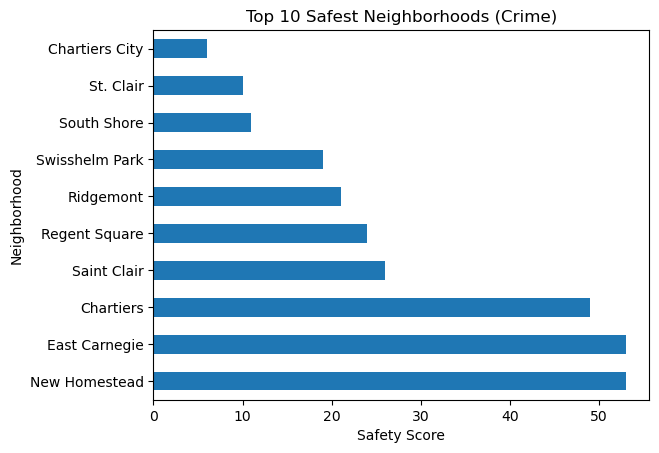

In [54]:
import matplotlib.pyplot as plt

top10_crime = neighborhood_scores_crime.head(10).reset_index()
top10_crime.columns = ["Neighborhood", "Safety Score"]

top10_crime

top10_crime.plot(kind="barh", x="Neighborhood", y="Safety Score", legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 Safest Neighborhoods (Crime)")
plt.xlabel("Safety Score")
plt.ylabel("Neighborhood")
plt.show()

Visualize which neighborhood is the safest from columns

In [55]:
import requests
import geopandas as gpd
from io import BytesIO

geo_url = "https://data.wprdc.org/dataset/e672f13d-71c4-4a66-8f38-710e75ed80a4/resource/4af8e160-57e9-4ebf-a501-76ca1b42fc99/download/neighborhoods.geojson"

response = requests.get(geo_url)

with open("neighborhoods.geojson", "wb") as f:
    f.write(response.content)

neighborhoods = gpd.read_file("neighborhoods.geojson")

In [56]:
neighborhoods.columns

Index(['OBJECTID', 'fid_blockg', 'statefp10', 'countyfp10', 'tractce10',
       'blkgrpce10', 'geoid10', 'namelsad10', 'mtfcc10', 'funcstat10',
       'aland10', 'awater10', 'intptlat10', 'intptlon10', 'shape_leng',
       'fid_neighb', 'perimeter', 'neighbor_', 'neighbor_i', 'hood', 'hood_no',
       'acres', 'sqmiles', 'dpwdiv', 'unique_id', 'sectors', 'shape_le_1',
       'shape_ar_1', 'page_number', 'plannerassign', 'created_user',
       'created_date', 'last_edited_user', 'last_edited_date', 'temp',
       'pghdb_sde_Neighborhood_2010_are', 'GlobalID', 'Shape__Area',
       'Shape__Length', 'geometry'],
      dtype='object')

In [57]:
df["weight"] = df["NIBRS_Offense_Category"].apply(get_weight)

In [58]:
crime_scores = df.groupby("Neighborhood")["weight"].sum().reset_index()

In [59]:
crime_scores.columns = ["Neighborhood", "crime_score"]

In [60]:
neighborhoods.head()

,OBJECTID,fid_blockg,statefp10,countyfp10,tractce10,blkgrpce10,geoid10,namelsad10,mtfcc10,funcstat10,...,created_user,created_date,last_edited_user,last_edited_date,temp,pghdb_sde_Neighborhood_2010_are,GlobalID,Shape__Area,Shape__Length,geometry
0,1,233,42,003,140500,3,420031405003,Block Group 3,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:13+00:00,None,7968760.0,a642a6b6-a2a9-48d5-acf2-3e2ce87d4bc0,8.417067e+06,14181.728584,"POLYGON ((-79.90531 40.45549, -79.90488 40.455..."
1,2,203,42,003,140100,3,420031401003,Block Group 3,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:41+00:00,None,34078712.0,20d4605b-258e-441a-a57e-a28fdabb6d30,3.410837e+07,30326.819418,"POLYGON ((-79.92063 40.44423, -79.92052 40.443..."
2,3,86,42,003,101700,2,420031017002,Block Group 2,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 12:59:55+00:00,None,12751163.0,bf4065e7-c29c-48bd-b529-e7fd99077238,1.275115e+07,14577.426328,"POLYGON ((-79.93546 40.47257, -79.9353 40.4725..."
3,4,214,42,003,050900,1,420030509001,Block Group 1,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 12:58:41+00:00,None,4997335.5,fed3fb32-0cd3-4556-aa41-17ee03b4fe41,4.897519e+06,13941.514356,"POLYGON ((-79.96601 40.4552, -79.96595 40.4548..."
4,5,173,42,003,300100,5,420033001005,Block Group 5,G5030,S,...,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:00:19+00:00,None,8411048.0,8669d2f0-b886-4519-99d0-bb1015b592b0,8.353046e+06,12021.860516,"POLYGON ((-79.98819 40.41852, -79.98824 40.418..."


In [61]:
crime_scores = df.groupby("Neighborhood")["weight"].sum().reset_index()

In [62]:
map_data = neighborhoods.merge(
    crime_scores,
    left_on="hood",
    right_on="Neighborhood",
    how="left"
)

In [63]:
neighborhood_scores = df.groupby("Neighborhood")["weight"].sum().sort_values()

In [64]:
neighborhood_scores.reset_index().columns

Index(['Neighborhood', 'weight'], dtype='object')

In [65]:
map_data.columns

Index(['OBJECTID', 'fid_blockg', 'statefp10', 'countyfp10', 'tractce10',
       'blkgrpce10', 'geoid10', 'namelsad10', 'mtfcc10', 'funcstat10',
       'aland10', 'awater10', 'intptlat10', 'intptlon10', 'shape_leng',
       'fid_neighb', 'perimeter', 'neighbor_', 'neighbor_i', 'hood', 'hood_no',
       'acres', 'sqmiles', 'dpwdiv', 'unique_id', 'sectors', 'shape_le_1',
       'shape_ar_1', 'page_number', 'plannerassign', 'created_user',
       'created_date', 'last_edited_user', 'last_edited_date', 'temp',
       'pghdb_sde_Neighborhood_2010_are', 'GlobalID', 'Shape__Area',
       'Shape__Length', 'geometry', 'Neighborhood', 'weight'],
      dtype='object')

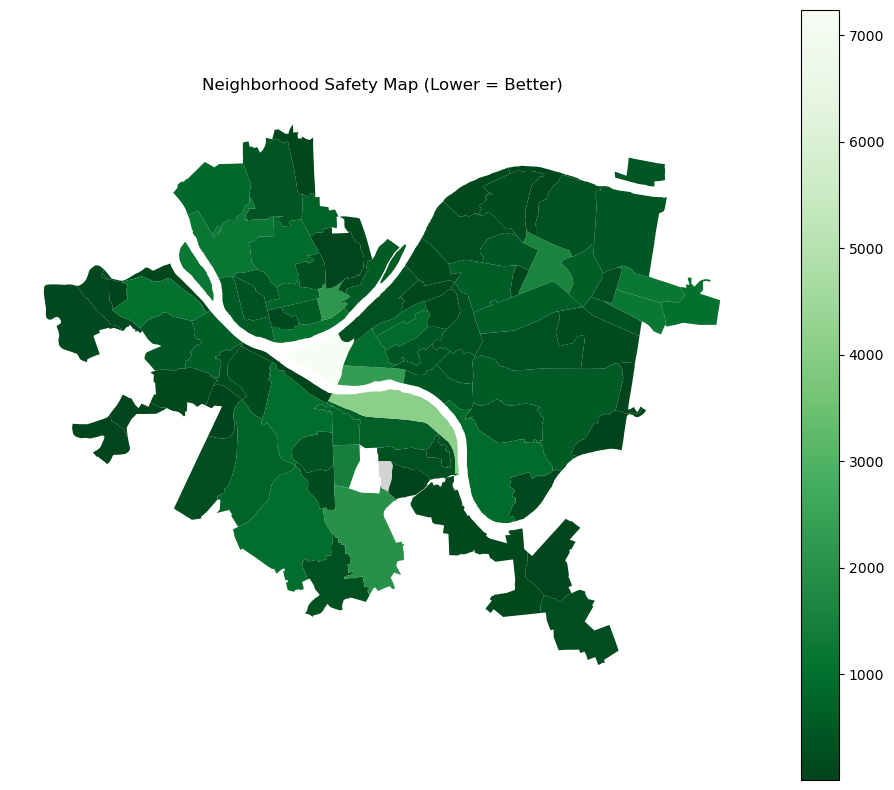

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

map_data.plot(
    column="weight",   # ✅ FIXED
    cmap="Greens_r",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

plt.title("Neighborhood Safety Map (Lower = Better)")
plt.axis("off")
plt.show()

In [67]:
map_data.columns

Index(['OBJECTID', 'fid_blockg', 'statefp10', 'countyfp10', 'tractce10',
       'blkgrpce10', 'geoid10', 'namelsad10', 'mtfcc10', 'funcstat10',
       'aland10', 'awater10', 'intptlat10', 'intptlon10', 'shape_leng',
       'fid_neighb', 'perimeter', 'neighbor_', 'neighbor_i', 'hood', 'hood_no',
       'acres', 'sqmiles', 'dpwdiv', 'unique_id', 'sectors', 'shape_le_1',
       'shape_ar_1', 'page_number', 'plannerassign', 'created_user',
       'created_date', 'last_edited_user', 'last_edited_date', 'temp',
       'pghdb_sde_Neighborhood_2010_are', 'GlobalID', 'Shape__Area',
       'Shape__Length', 'geometry', 'Neighborhood', 'weight'],
      dtype='object')

Saftey score is now attatched to a map given from previous data in this metric. In conclusion, Ridgemont seems to be the safest neigborhood within crime in our metric according to arrest reports.

# Metric #2: Housing Violations reports

In [68]:
df.columns

Index(['_id', 'Template', 'Case_Number', 'ArrestPerson_ID', 'Arrest_Date',
       'Arrest_Year', 'Arrest_Month', 'Arrest_Time', 'Type',
       'ArrestPerson_Age', 'ArrestPerson_Sex', 'ArrestPerson_Race',
       'NIBRS_Coded_Offense', 'NIBRS_Offense_Code', 'NIBRS_Offense_Category',
       'NIBRS_Offense_Type', 'NIBRS_Crime_Against', 'NIBRS_Offense_Grouping',
       'Violation', 'Zone', 'Tract', 'Neighborhood',
       'ArrestCharge_Felony_Misdemeanor_Description', 'XCOORD', 'YCOORD',
       'Block_Address', 'weight'],
      dtype='object')

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.wprdc.org/datastore/dump/70c06278-92c5-4040-ab28-17671866f81c"
df = pd.read_csv(url)

df.head()

,_id,casefile_number,address,parcel_id,status,case_file_type,investigation_date,investigation_outcome,investigation_findings,violation_description,...,violation_spec_instructions,court_date,court_time,docket_number,court_decision,latitude,longitude,neighborhood,ward,council_district
0,8590660,CF-PLI-2023-025162,"118 E AGNEW AVE, Pittsburgh, PA 15210-",0060S00244000000,Closed,Broken Sidewalk,2023-09-21,Violation Resolved,Violations have been corrected.,NaN,...,NaN,NaN,NaN,NaN,NaN,40.395387,-79.985248,Carrick,29.0,4
1,8590661,CF-PLI-2023-025162,"118 E AGNEW AVE, Pittsburgh, PA 15210-",0060S00244000000,Closed,Broken Sidewalk,2023-08-17,Violation Found,Violation remains,NaN,...,NaN,NaN,NaN,NaN,NaN,40.395387,-79.985248,Carrick,29.0,4
2,8590662,CF-PLI-2023-025162,"118 E AGNEW AVE, Pittsburgh, PA 15210-",0060S00244000000,Closed,Broken Sidewalk,2023-09-19,Filing Court Paperwork,Violations remain until permit is completed.,NaN,...,NaN,NaN,NaN,NaN,NaN,40.395387,-79.985248,Carrick,29.0,4
3,8590663,CF-PLI-2023-025162,"118 E AGNEW AVE, Pittsburgh, PA 15210-",0060S00244000000,Closed,Broken Sidewalk,2023-07-21,Violation Found,Violations have been cited.,NaN,...,NaN,NaN,NaN,NaN,NaN,40.395387,-79.985248,Carrick,29.0,4
4,8590664,CF-PLI-2023-025162,"118 E AGNEW AVE, Pittsburgh, PA 15210-",0060S00244000000,Closed,Broken Sidewalk,NaN,NaN,NaN,"Sidewalks, walkways, stairs, driveways, parkin...",...,Repair or replace the sidewalk where it has br...,NaN,NaN,NaN,NaN,40.395387,-79.985248,Carrick,29.0,4


In [90]:
df["violation_score"] = 1

In [91]:
neighborhood_scores_pli = df.groupby("neighborhood")["violation_score"].sum().sort_values()

In [92]:
df["violation_score"] = 1

neighborhood_scores = df.groupby("neighborhood")["violation_score"].sum().sort_values()

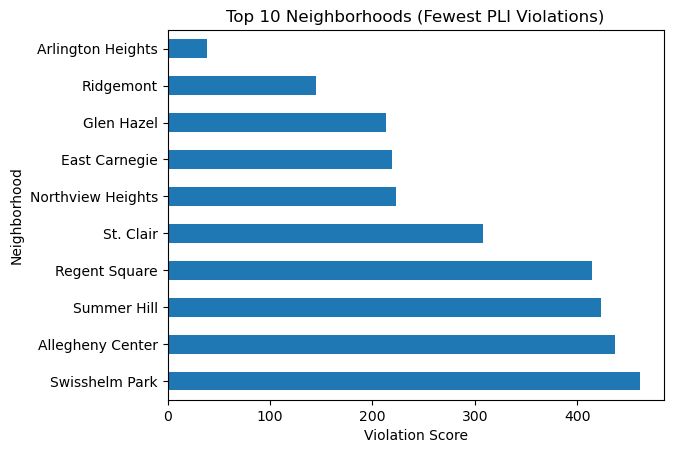

In [93]:
top10_pli = neighborhood_scores_pli.head(10).reset_index()
top10_pli.columns = ["Neighborhood", "Violation Score"]

top10_pli  # optional display

top10_pli.plot(kind="barh", x="Neighborhood", y="Violation Score", legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 Neighborhoods (Fewest PLI Violations)")
plt.xlabel("Violation Score")
plt.ylabel("Neighborhood")
plt.show()

Clean dataset of of violations for visualization up above

In [94]:
top10 = neighborhood_scores_pli.head(10).reset_index()
top10.columns = ["Neighborhood", "Violation Score"]

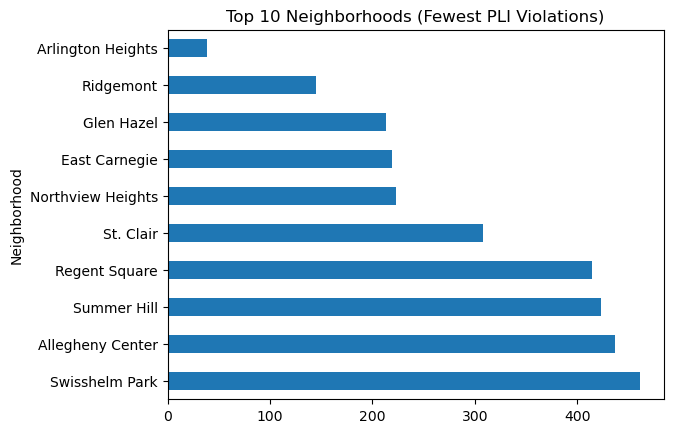

In [95]:
import matplotlib.pyplot as plt

top10.plot(
    kind="barh",
    x="Neighborhood",
    y="Violation Score",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Top 10 Neighborhoods (Fewest PLI Violations)")
plt.show()

Visually shows which neighborhood has fewest violations. Ridgemont has fewest violations in the chart according to the data we were given.

Metric #3

Personal Reflection

Conclusion